<a href="https://colab.research.google.com/github/Asigen93/Measurement-Report-Skripsi/blob/main/Measurement_Report_Lengkap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

import pandas as pd
import numpy as np
import re
from google.colab import files


# Upload
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Baca tanpa header otomatis
raw = pd.read_excel(filename, header=None)

# Rename kolom sementara
raw.columns = range(raw.shape[1])

clean_rows = []
current_day = None

for _, row in raw.iterrows():

    first_cell = str(row[0]).strip() if pd.notna(row[0]) else ''

    # Deteksi Hari
    day_match = re.match(r'Hari\s*(\d+)', first_cell, re.IGNORECASE)
    if day_match:
        current_day = int(day_match.group(1))
        continue

    # Skip header / kosong
    if pd.isna(row[2]) or str(row[2]).strip() in ['Skenario (Lock)', '(20 mb)']:
        continue

    # Ambil data valid
    clean_rows.append({
        'Hari': current_day,
        'No': row[1],
        'Skenario (Lock)': row[2],
        'Timing Advance': row[3],
        'Band': row[4],
        'Bandwidth': row[5],
        'RSRP (dBm)': row[6],
        'RSRQ (dB)': row[7],
        'SNR (dB)': row[8],
        'Time DL': row[9],
        'Time UL': row[10],
        'Throughput DL (Mbps)': row[11],
        'Throughput UL (Mbps)': row[12],
        'Kategori': row[13] if len(row) > 13 else None
    })

df = pd.DataFrame(clean_rows)

print(df.head())
print("\nJumlah Data Bersih:", len(df))

Saving Buat measurement Report.xlsx to Buat measurement Report (2).xlsx
   Hari  No      Skenario (Lock) Timing Advance       Band  Bandwidth  \
0     1  1.   EARFCN 500 PCI 261        ± 312 m  B1 (2100)         20   
1     1  2.  EARFCN 1850 PCI 261        ± 312 m  B3 (1800)         20   
2     1  3.  EARFCN 3500 PCI 261        ± 312 m   B8 (900)         10   
3     1  4.   EARFCN 500 PCI 214        ± 156 m  B1 (2100)         20   
4     1  5.  EARFCN 3500 PCI 214        ± 156 m   B8 (900)         10   

   RSRP (dBm)  RSRQ (dB)  SNR (dB)   Time DL   Time UL  Throughput DL (Mbps)  \
0         -91        -14       4.8  16 detik  32 detik                  10.0   
1         -93        -13      20.0  19 detik  24 detik                   8.4   
2         -79        -11       8.2  58 detik  27 detik                   2.8   
3         -88        -10      30.0  14 detik  26 detik                  11.4   
4         -77        -10      -4.0  58 detik  30 detik                   2.8   

   Throu

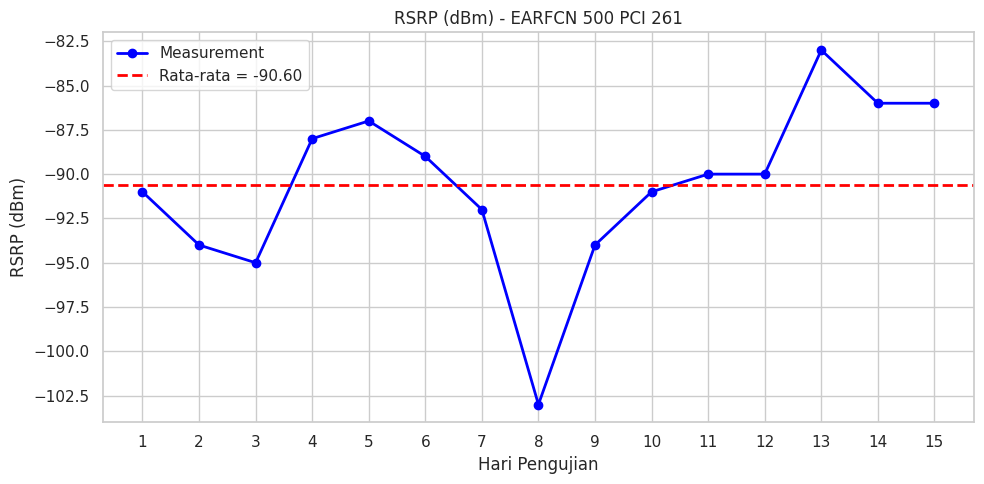

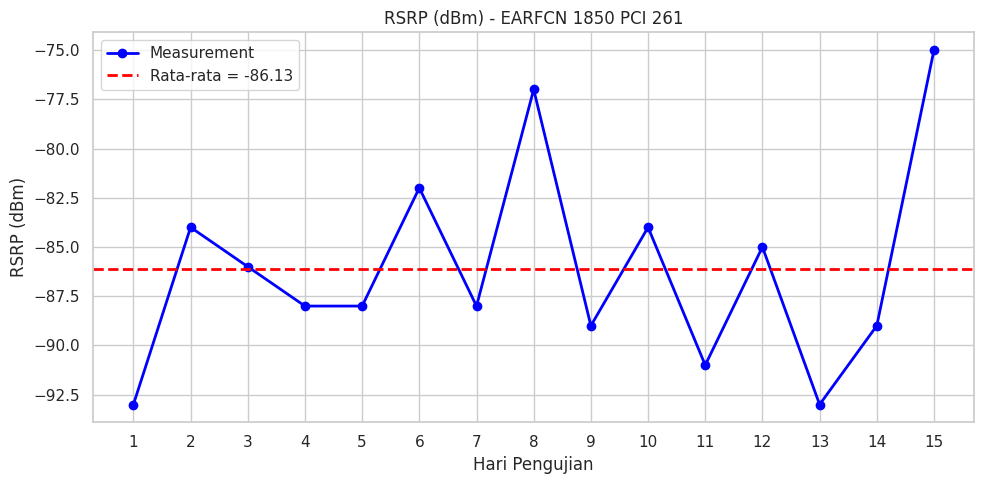

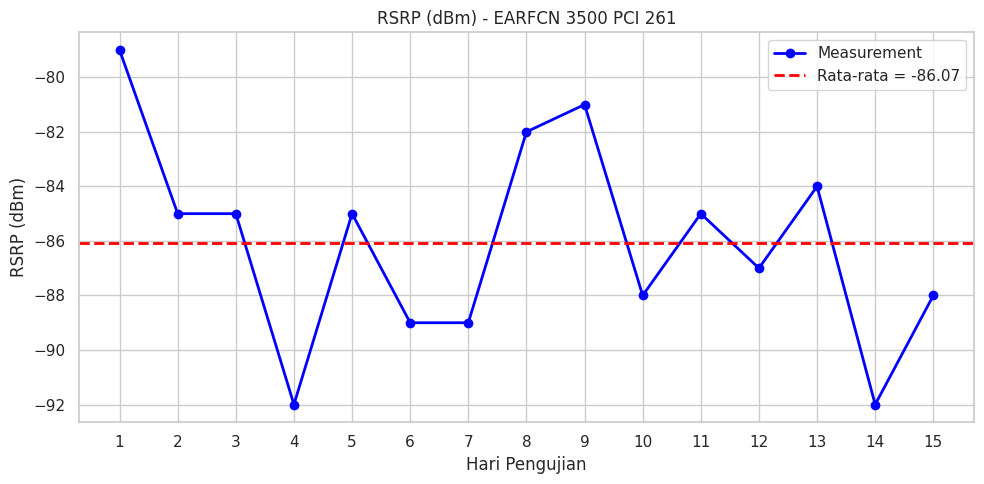

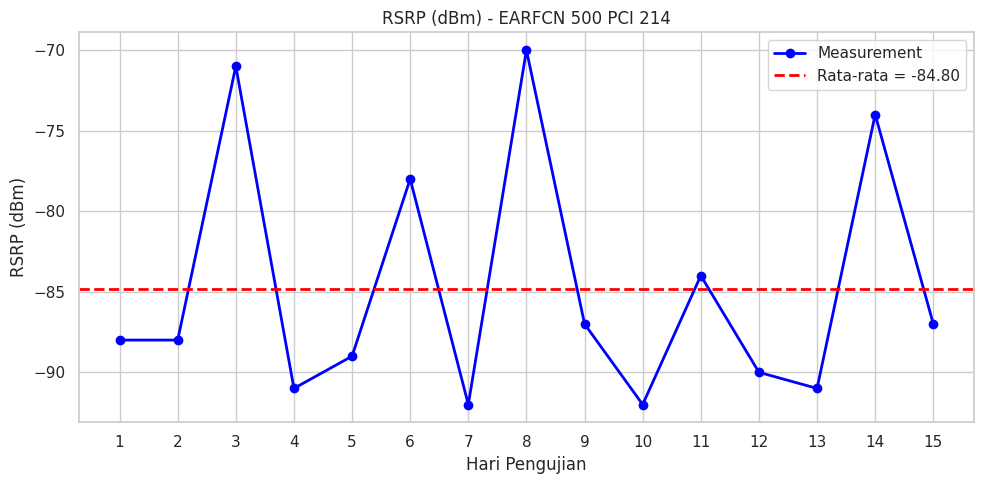

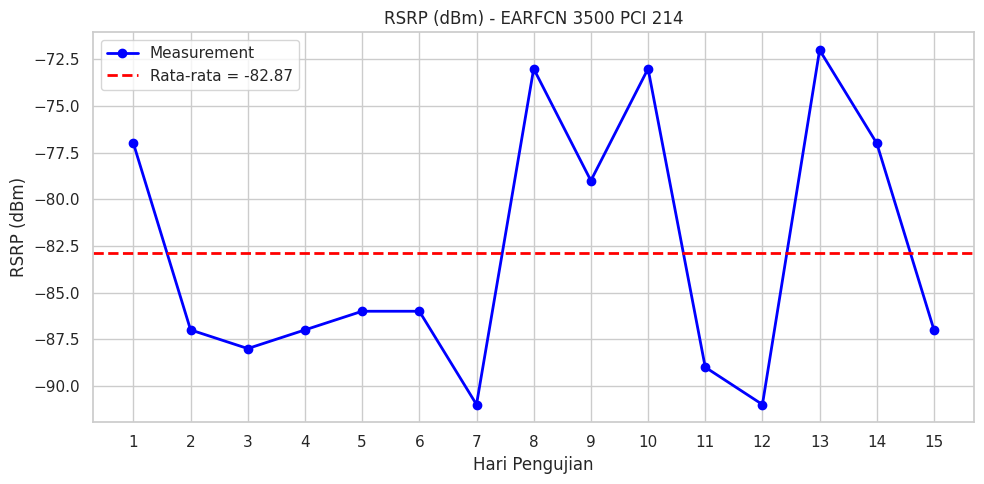

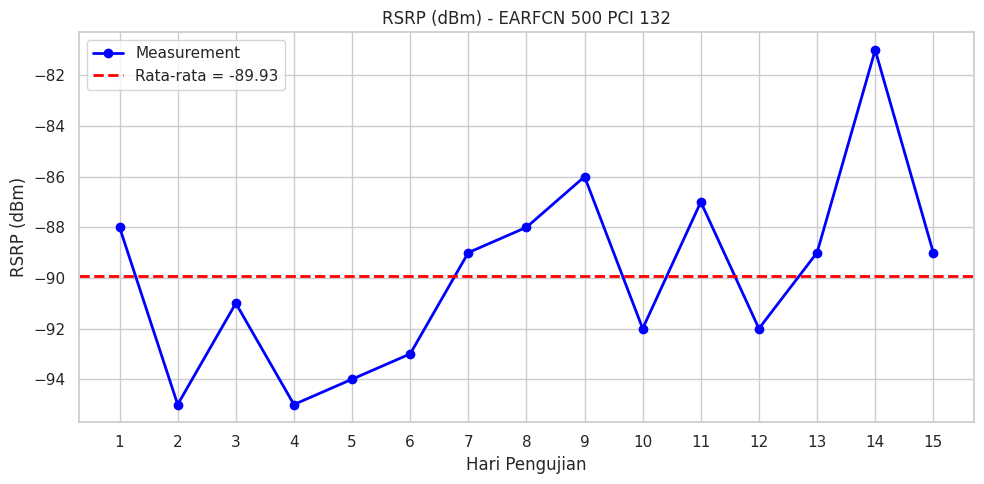

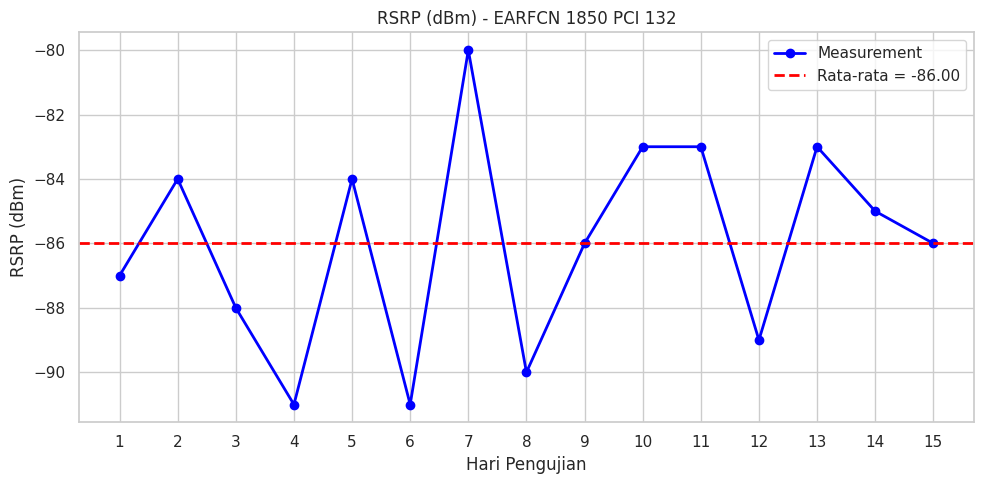

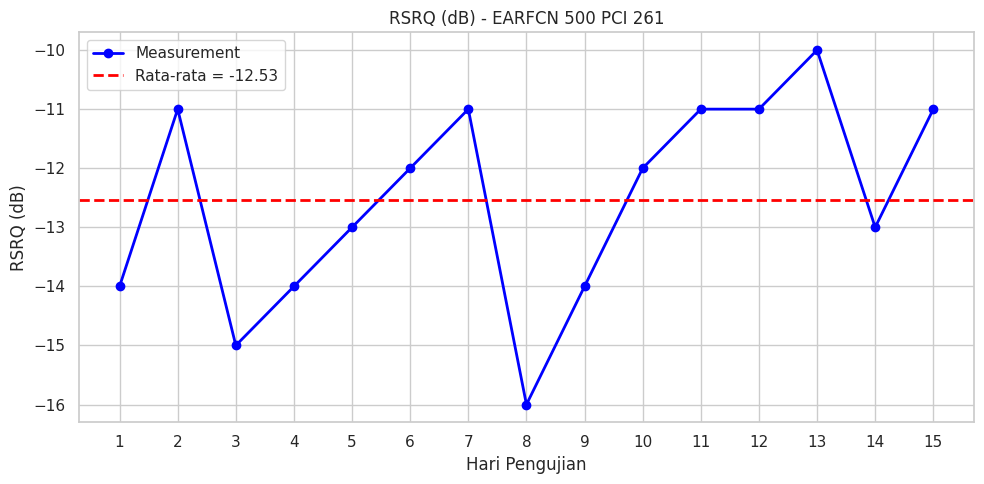

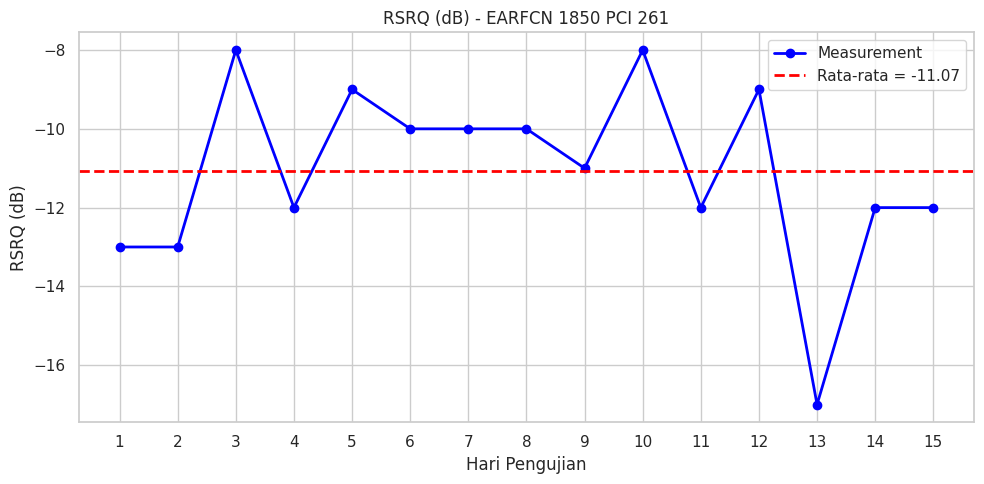

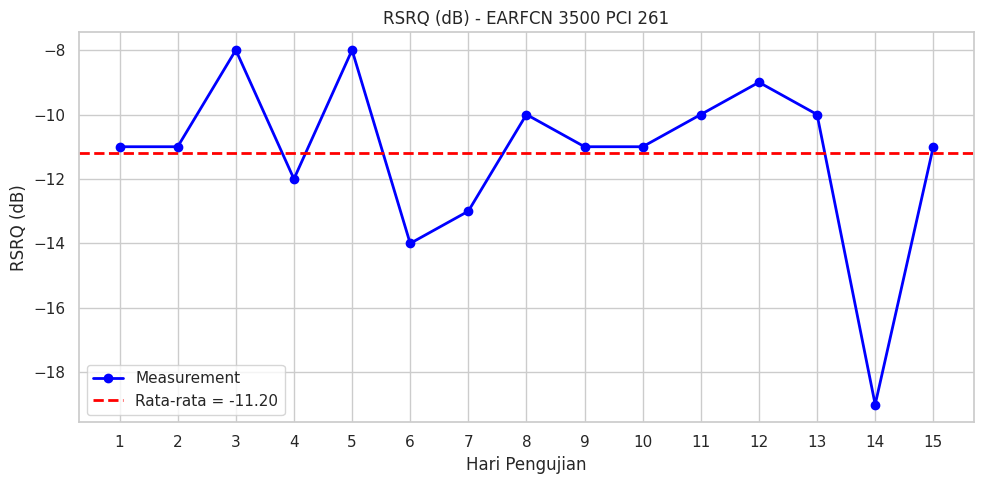

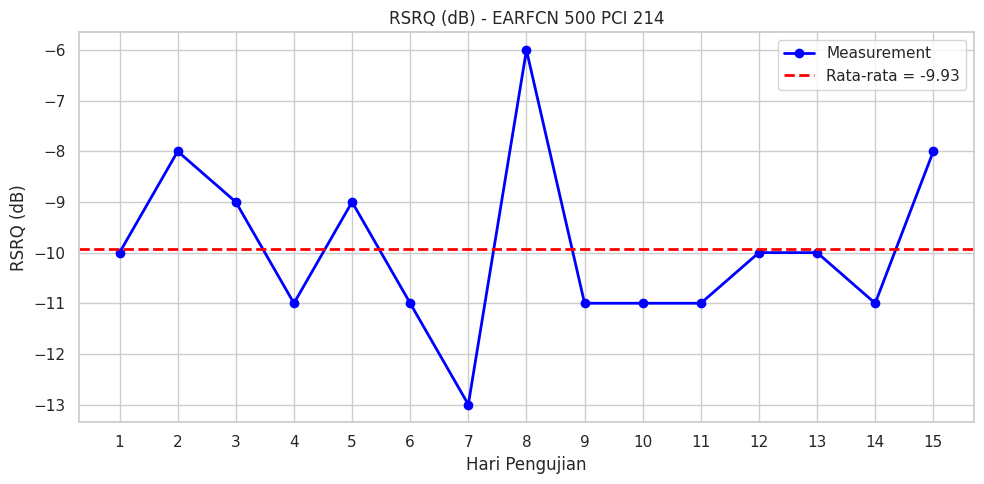

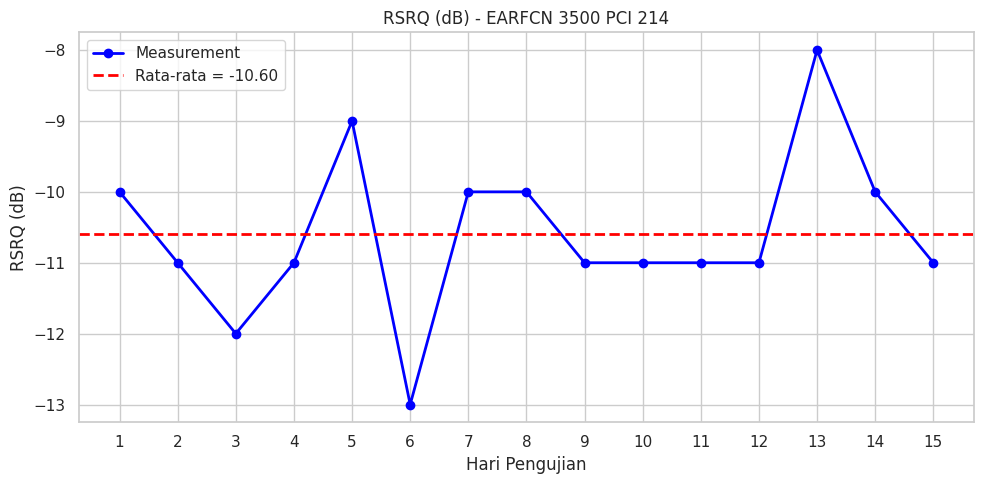

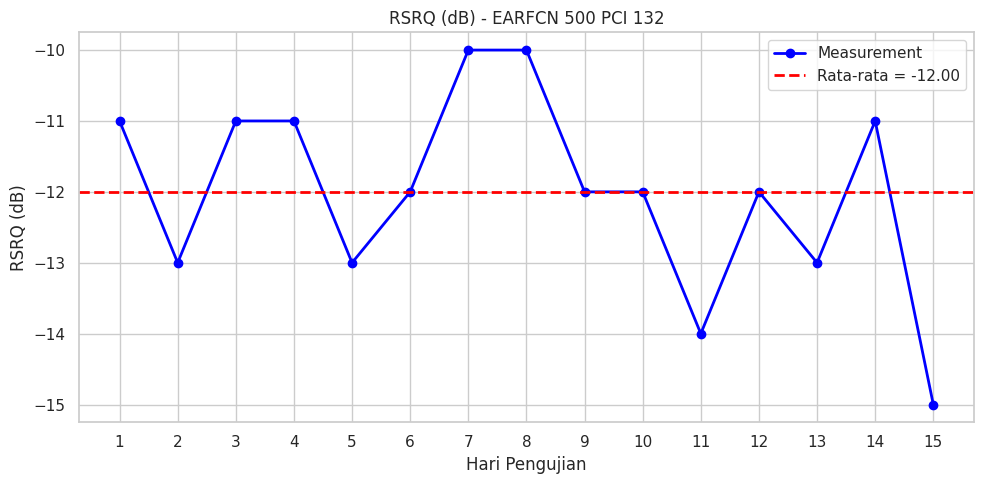

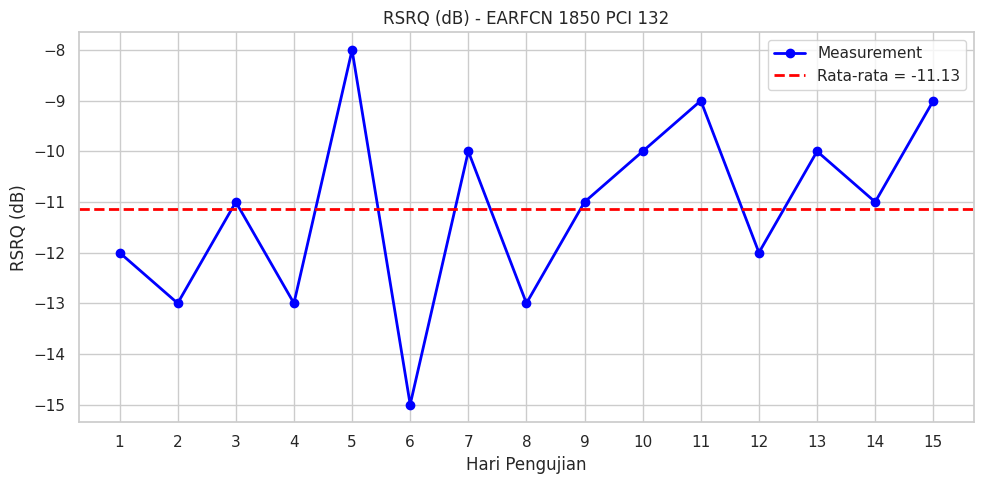

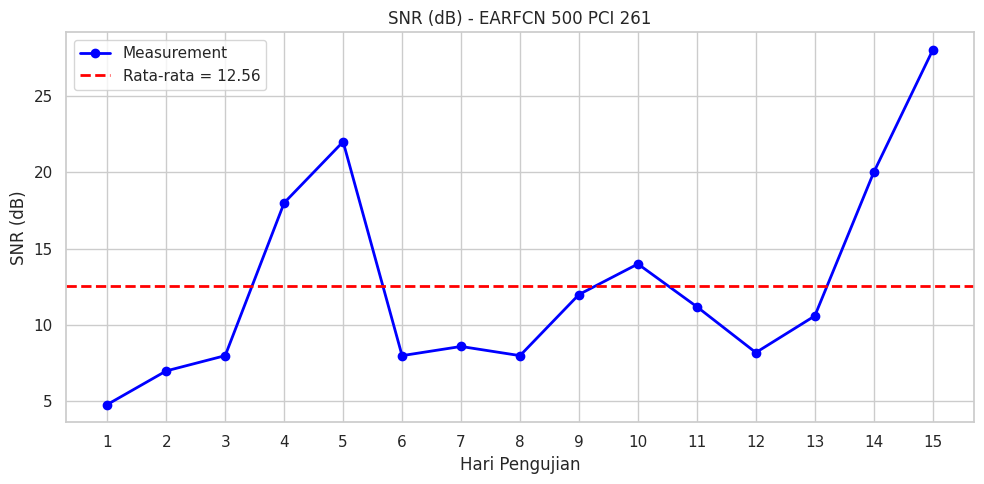

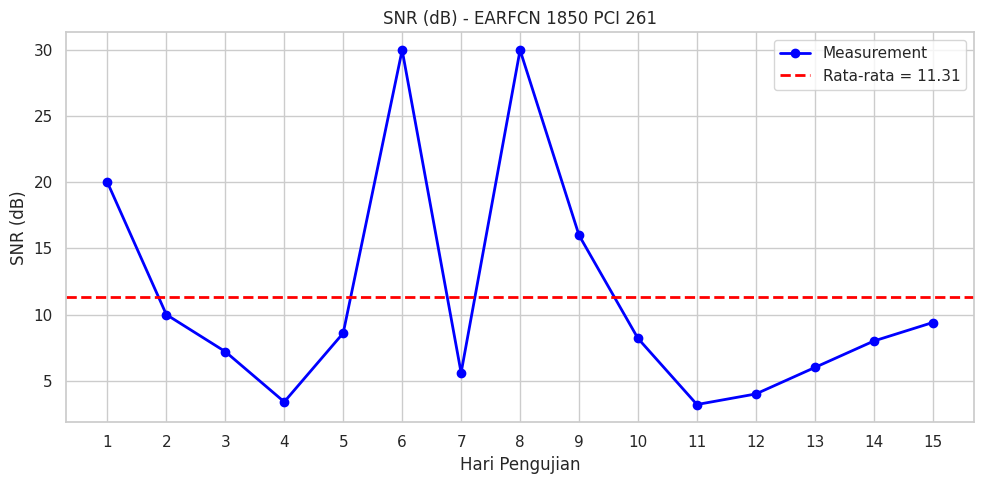

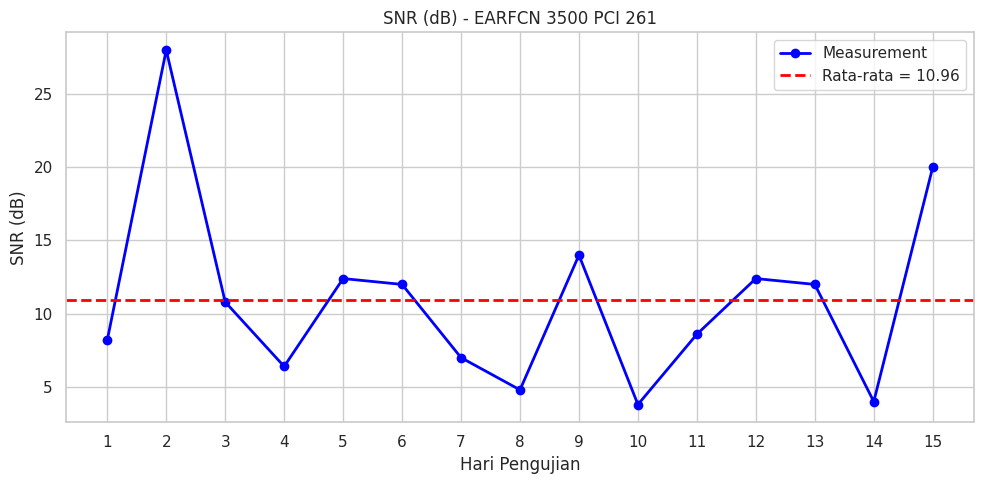

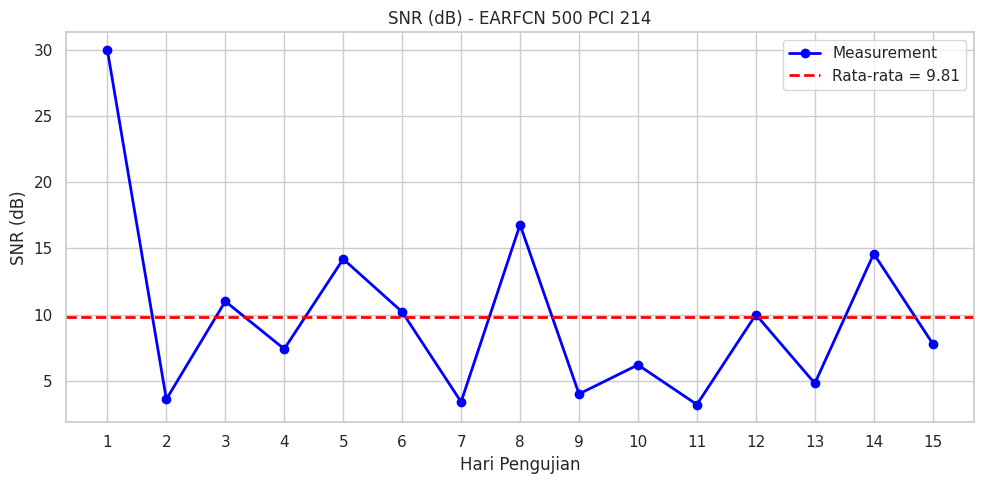

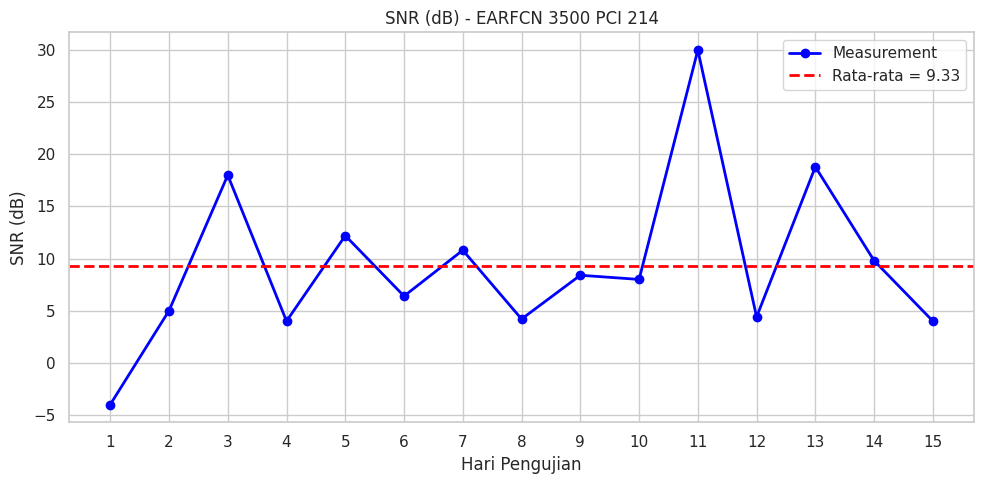

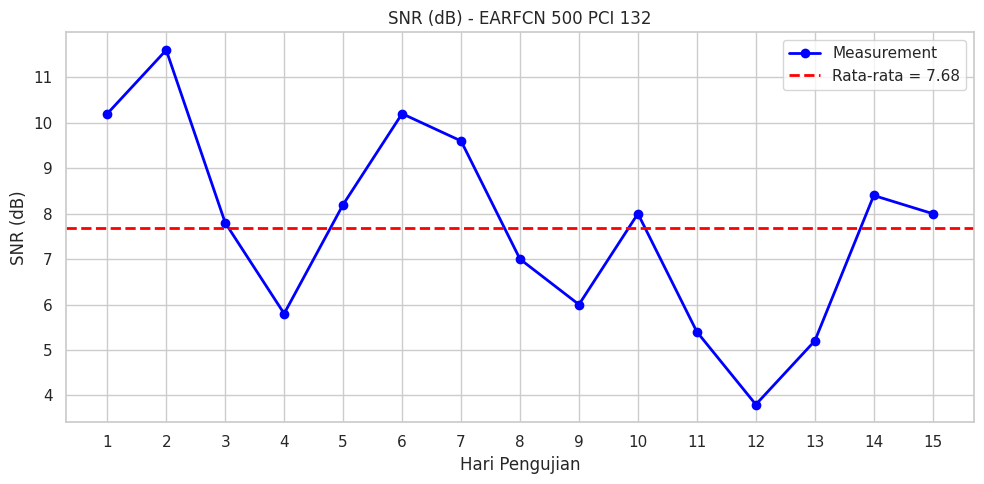

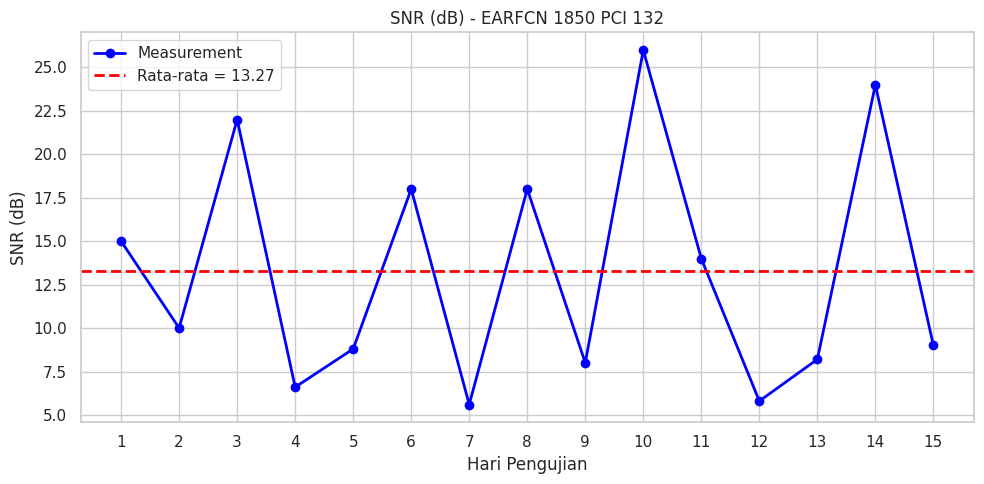

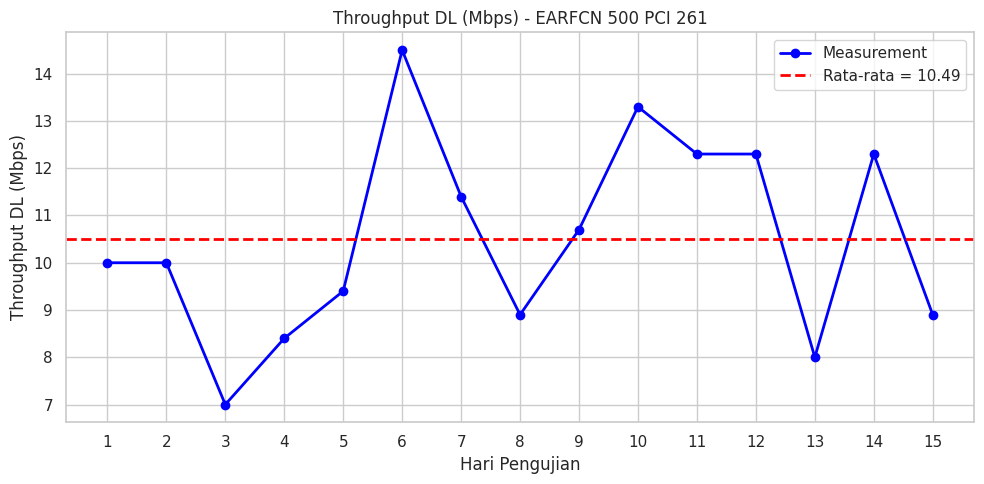

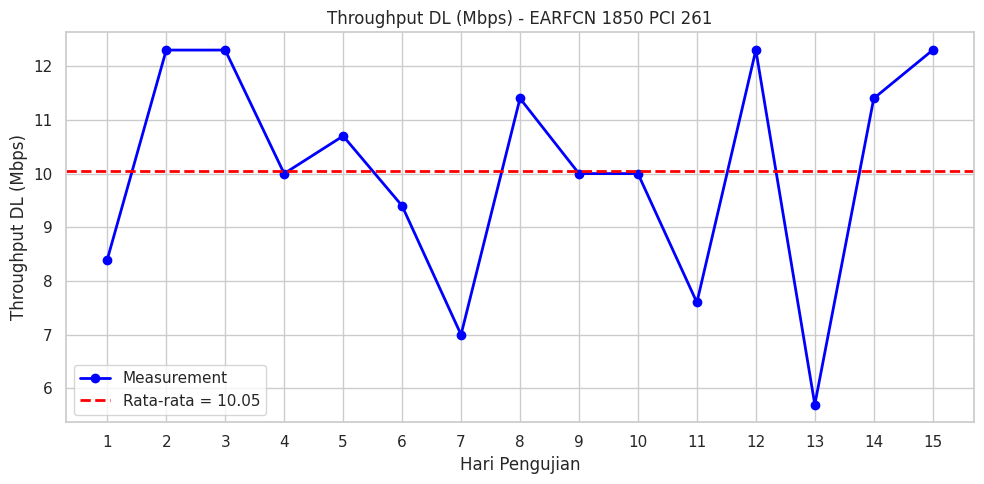

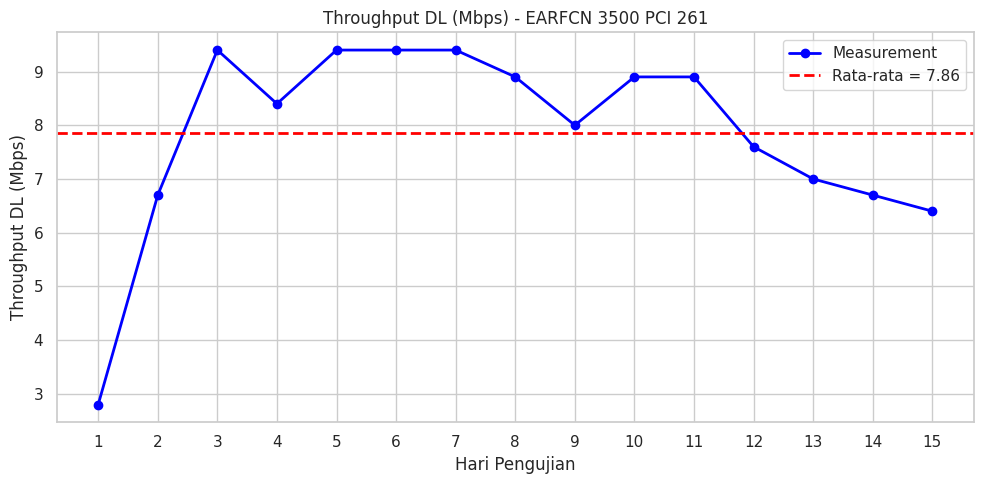

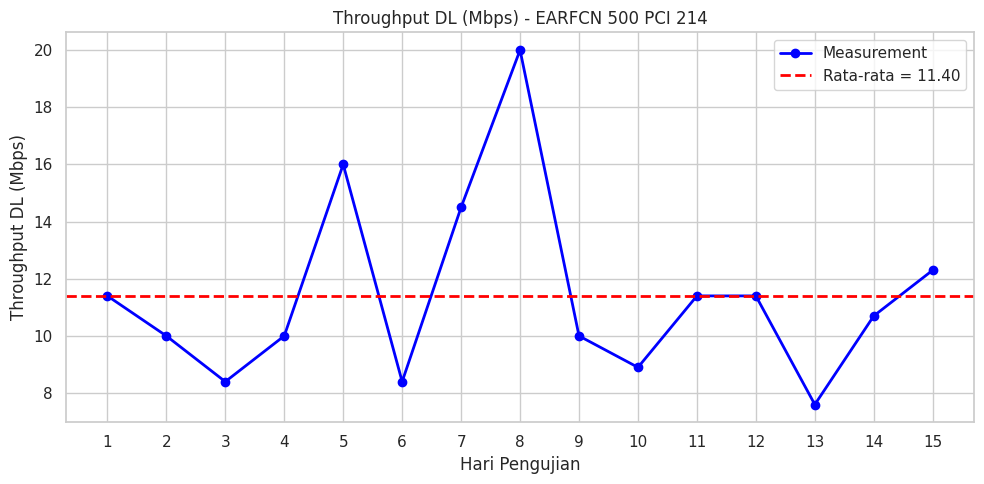

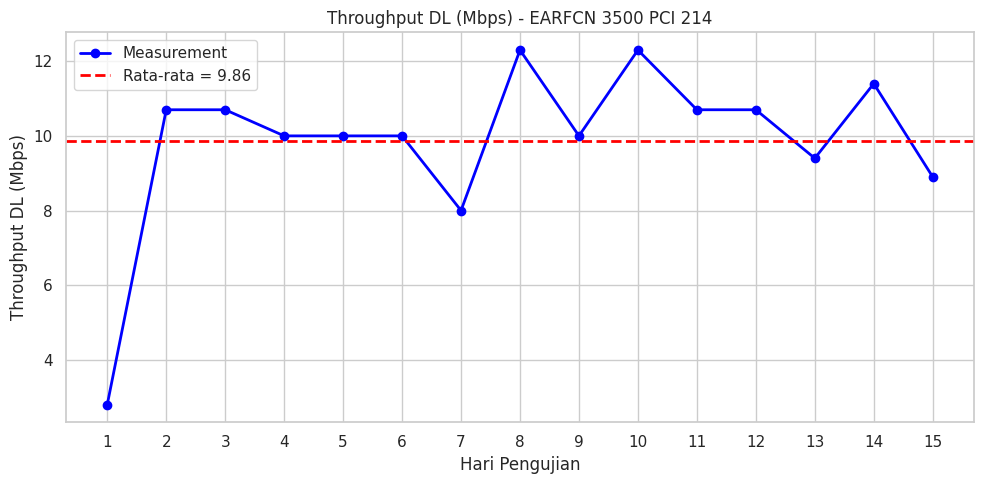

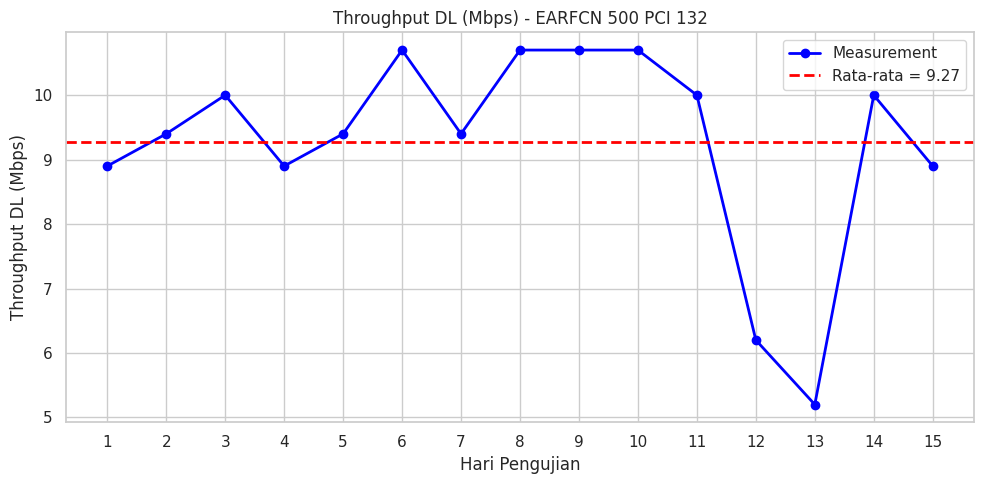

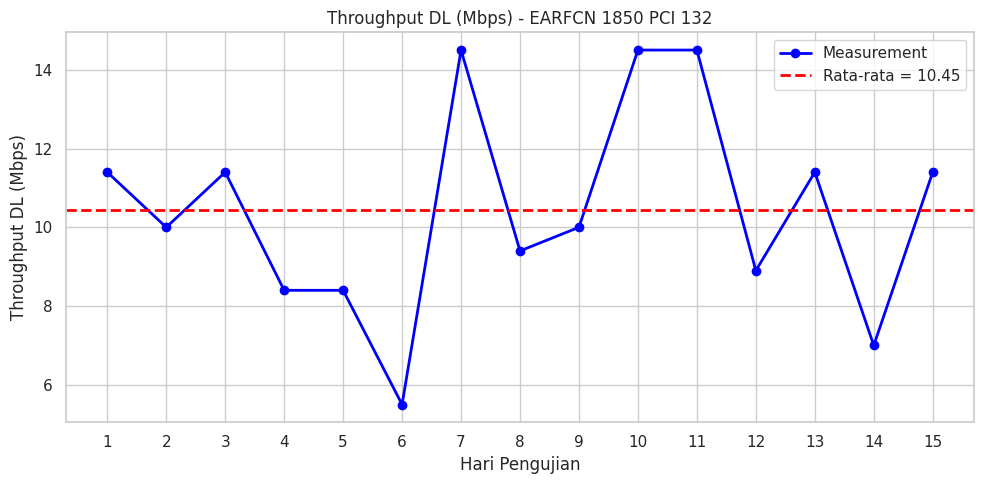

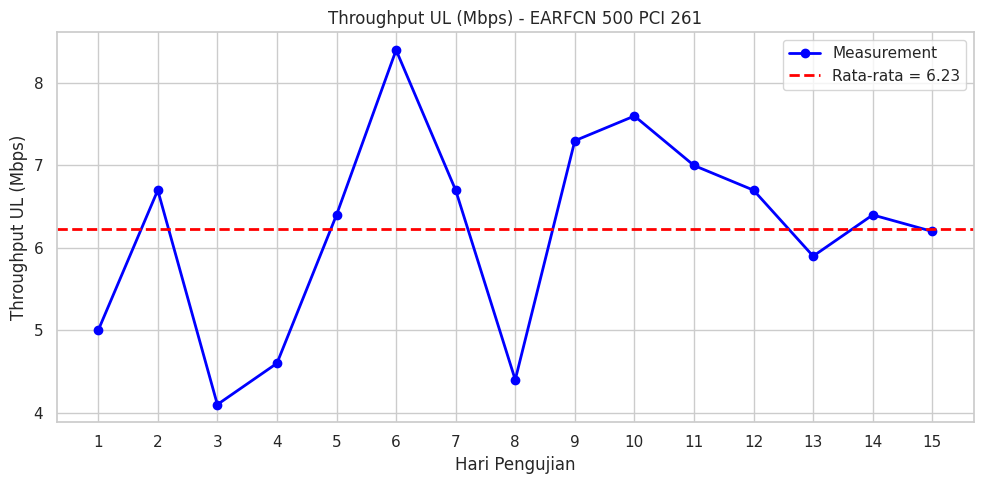

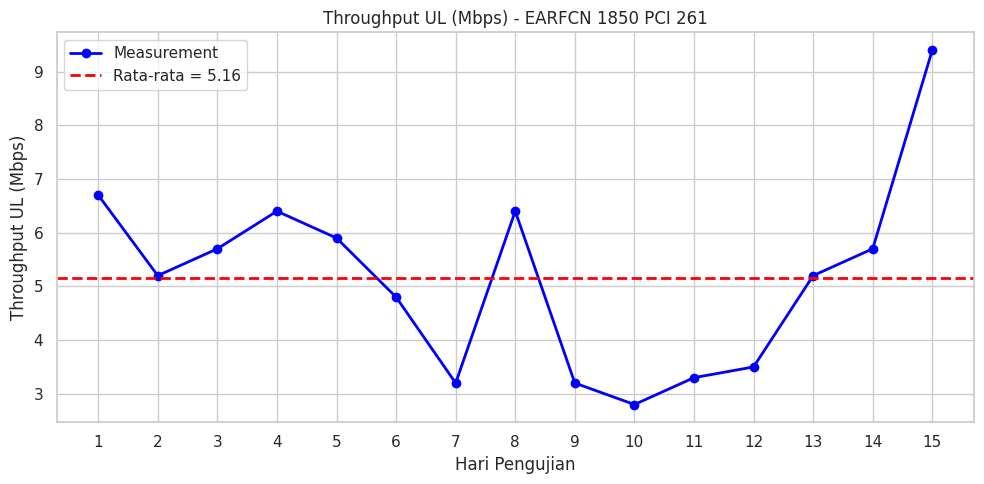

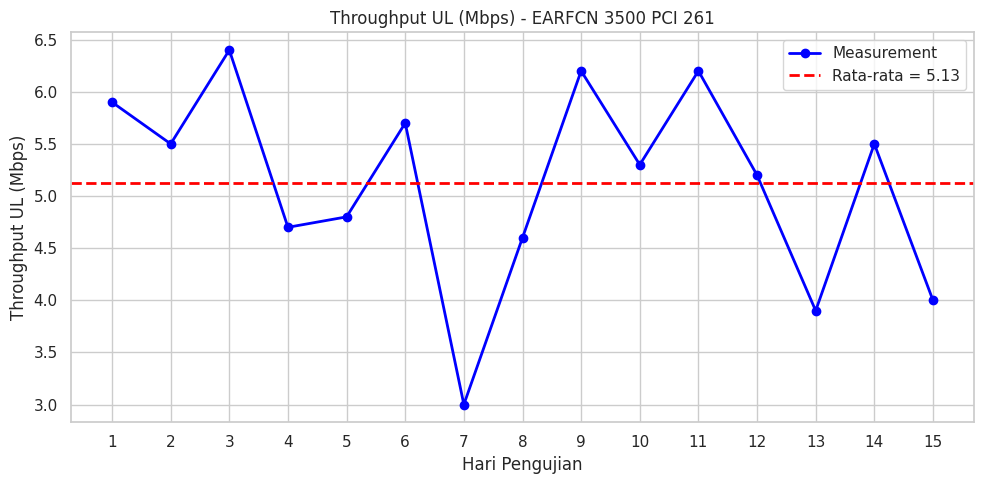

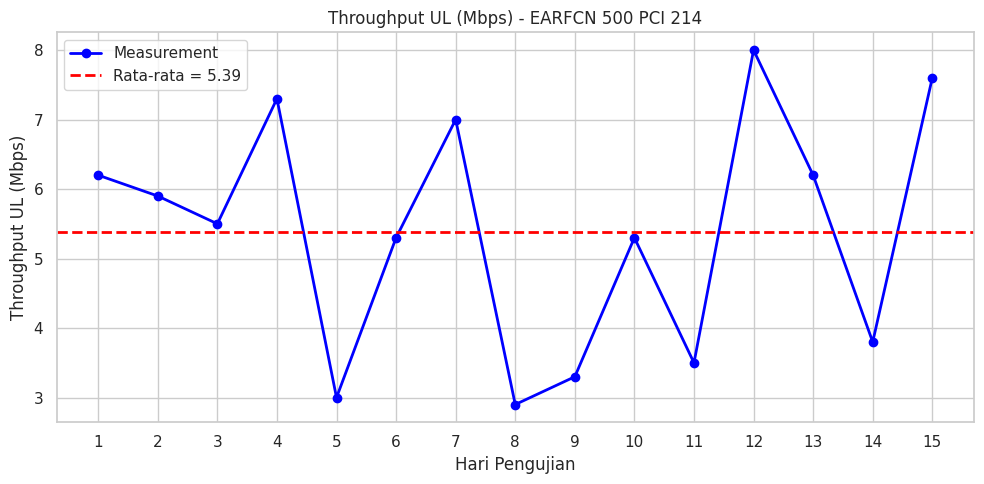

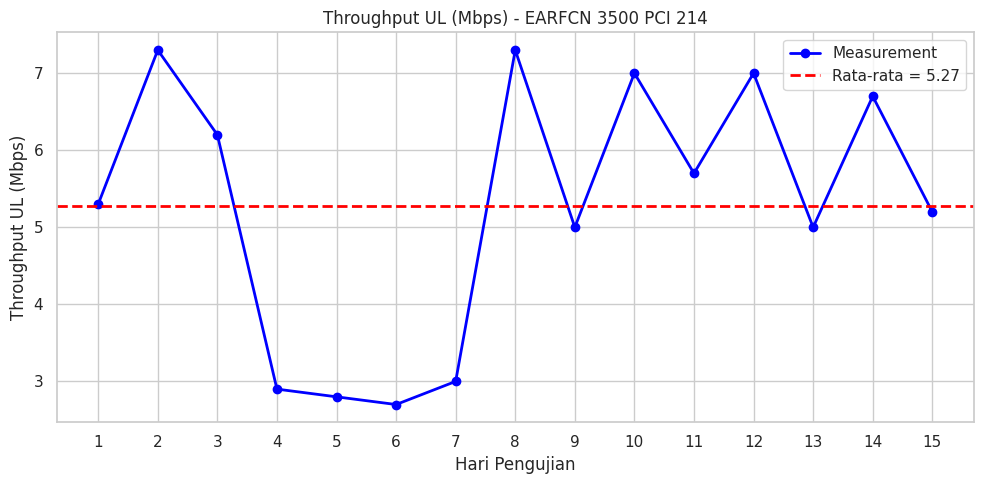

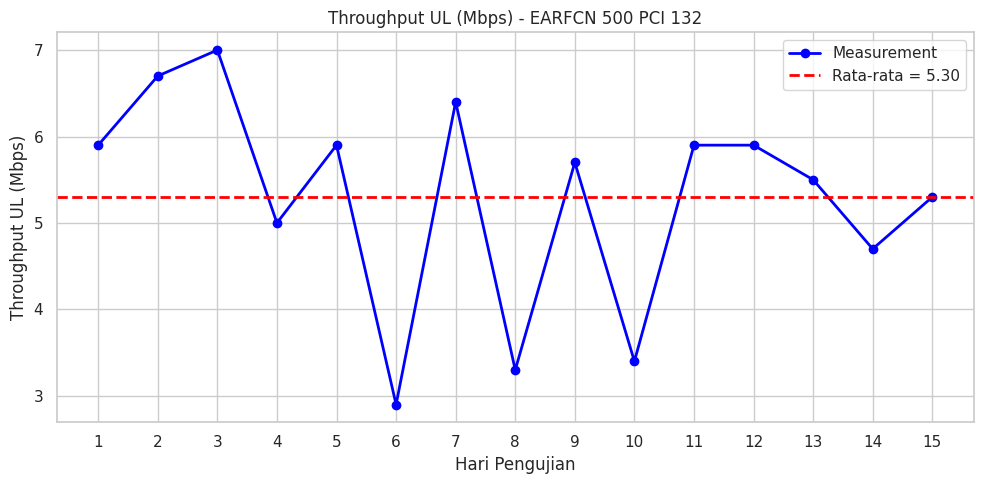

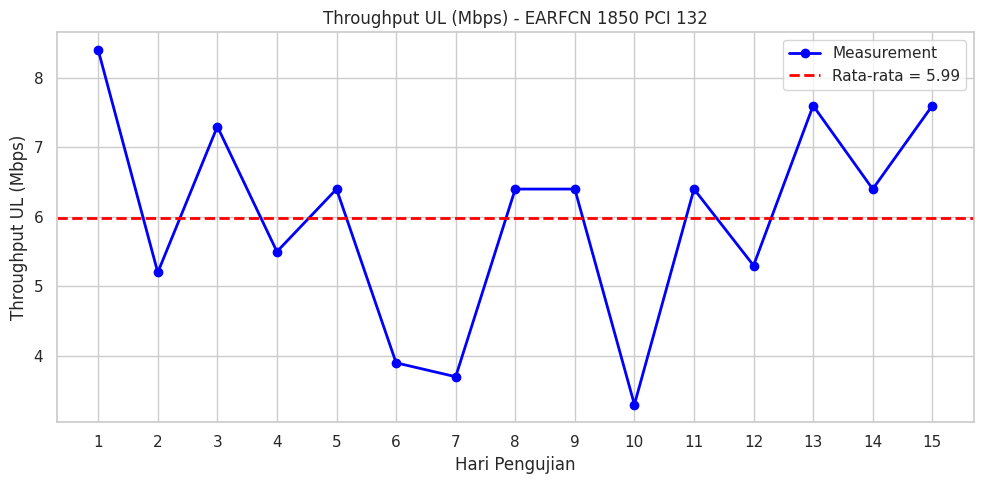

In [6]:
sns.set(style="whitegrid")

numeric_cols = [
    'RSRP (dBm)',
    'RSRQ (dB)',
    'SNR (dB)',
    'Throughput DL (Mbps)',
    'Throughput UL (Mbps)'
]

# Konversi numerik
for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '.'),
        errors='coerce'
    )

# Plot per parameter dan per skenario
for param in numeric_cols:

    for skenario in df['Skenario (Lock)'].unique():

        temp = df[df['Skenario (Lock)'] == skenario].sort_values('Hari')

        plt.figure(figsize=(10,5))

        mean_val = temp[param].mean()

        plt.plot(
            temp['Hari'],
            temp[param],
            marker='o',
            linewidth=2,
            color='blue',
            label='Measurement'
        )

        plt.axhline(
            y=mean_val,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Rata-rata = {mean_val:.2f}'
        )

        plt.title(f'{param} - {skenario}')
        plt.xlabel('Hari Pengujian')
        plt.ylabel(param)
        plt.xticks(range(1,16))
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()